<a href="https://colab.research.google.com/github/bilalsherifdeen1-ux/AI-Project-Gallery/blob/main/My-FlyRank-AI-project/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install duckdb datasets scikit-learn --quiet

from google.colab import userdata
import duckdb

con = duckdb.connect()
con.sql("INSTALL httpfs;")
con.sql("LOAD httpfs;")
con.sql(f"""
CREATE SECRET hf_secret (
TYPE huggingface,
TOKEN '{userdata.get("HF_TOKEN")}'
);
""")

print("Setup complete.")

Setup complete.


In [2]:
MONTH = "2026-03"
PRIOR_MONTH = "2026-02"
ELIGIBILITY_MIN_IMPRESSIONS = 100
SCORE_THRESHOLD = 0.0005

print(f"Scoring month: {MONTH}")
print(f"Eligibility gate: impressions >= {ELIGIBILITY_MIN_IMPRESSIONS}")
print(f"Flag threshold: predicted_ctr - actual_ctr > {SCORE_THRESHOLD}")

Scoring month: 2026-03
Eligibility gate: impressions >= 100
Flag threshold: predicted_ctr - actual_ctr > 0.0005


In [4]:
import duckdb
from google.colab import userdata

con = duckdb.connect()
con.sql("INSTALL httpfs;")
con.sql("LOAD httpfs;")
con.sql(f"""
CREATE SECRET hf_secret (
    TYPE huggingface,
    TOKEN '{userdata.get("HF_TOKEN")}'
);
""")

MARCH_PATH = f"hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month={MONTH}/*.parquet"
CONTENT_PATH = "hf://datasets/FlyRank/internship-warehouse/dim_content.parquet"

feature_query = f"""
WITH agg AS (
    SELECT
        client_hash_id, content_hash_id,
        SUM(gsc_clicks) AS clicks,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_avg_position * gsc_impressions) / NULLIF(SUM(gsc_impressions), 0) AS avg_position
    FROM read_parquet('{MARCH_PATH}')
    GROUP BY client_hash_id, content_hash_id
    HAVING SUM(gsc_impressions) >= {ELIGIBILITY_MIN_IMPRESSIONS}
)
SELECT
    a.client_hash_id, a.content_hash_id,
    a.avg_position, a.impressions,
    d.main_intent, d.search_volume, d.category_count,
    a.clicks * 1.0 / NULLIF(a.impressions, 0) AS actual_ctr
FROM agg a
JOIN read_parquet('{CONTENT_PATH}') d ON a.content_hash_id = d.content_hash_id
"""
df = con.sql(feature_query).df().dropna(subset=["actual_ctr", "avg_position", "main_intent",
                                                 "search_volume", "category_count", "impressions"])
numeric_cols = ["avg_position", "impressions", "search_volume", "category_count"]
df[numeric_cols] = df[numeric_cols].astype("float64")
print(f"Eligible analysis set: {df.shape[0]} rows, {df.shape[1]} columns")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Eligible analysis set: 99197 rows, 8 columns


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import mean_absolute_error
import numpy as np

numeric_features = ["avg_position", "impressions", "search_volume", "category_count"]
categorical_features = ["main_intent"]

def make_model():
    pre = ColumnTransformer([
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ])
    return Pipeline([
        ("pre", pre),
        ("rf", RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)),
    ])

X = df[numeric_features + categorical_features]
y = df["actual_ctr"]

def position_band(pos):
    if pos <= 3: return "1-3"
    elif pos <= 6: return "4-6"
    elif pos <= 10: return "7-10"
    elif pos <= 20: return "11-20"
    else: return "21+"

df["_band"] = df["avg_position"].apply(position_band)
band_avg_ctr = df.groupby("_band")["actual_ctr"].mean()
baseline_pred = df["_band"].map(band_avg_ctr)
baseline_mae = mean_absolute_error(y, baseline_pred)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y, test_size=0.25, random_state=42)
naive_model = make_model()
naive_model.fit(X_train_r, y_train_r)
naive_mae = mean_absolute_error(y_test_r, naive_model.predict(X_test_r))

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["client_hash_id"]))
X_train_g, X_test_g = X.iloc[train_idx], X.iloc[test_idx]
y_train_g, y_test_g = y.iloc[train_idx], y.iloc[test_idx]

grouped_model = make_model()
grouped_model.fit(X_train_g, y_train_g)
grouped_mae = mean_absolute_error(y_test_g, grouped_model.predict(X_test_g))

print(f"Baseline MAE: {baseline_mae:.5f}")
print(f"Naive random-split MAE: {naive_mae:.5f}  (falsely optimistic — confirms the leak)")
print(f"Client-grouped-split MAE: {grouped_mae:.5f}")

Baseline MAE: 0.00250
Naive random-split MAE: 0.00243  (falsely optimistic — confirms the leak)
Client-grouped-split MAE: 0.00268


In [6]:
FEB_PATH = f"hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month={PRIOR_MONTH}/*.parquet"

feb_query = f"""
WITH agg AS (
    SELECT
        client_hash_id, content_hash_id,
        SUM(gsc_clicks) AS clicks,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_avg_position * gsc_impressions) / NULLIF(SUM(gsc_impressions), 0) AS avg_position
    FROM read_parquet('{FEB_PATH}')
    GROUP BY client_hash_id, content_hash_id
    HAVING SUM(gsc_impressions) >= {ELIGIBILITY_MIN_IMPRESSIONS}
)
SELECT
    a.client_hash_id, a.content_hash_id,
    a.avg_position, a.impressions,
    d.main_intent, d.search_volume, d.category_count,
    a.clicks * 1.0 / NULLIF(a.impressions, 0) AS actual_ctr
FROM agg a
JOIN read_parquet('{CONTENT_PATH}') d ON a.content_hash_id = d.content_hash_id
"""
df_feb = con.sql(feb_query).df().dropna(subset=["actual_ctr", "avg_position", "main_intent",
                                                  "search_volume", "category_count", "impressions"])
df_feb[numeric_cols] = df_feb[numeric_cols].astype("float64")

time_aware_model = make_model()
time_aware_model.fit(df_feb[numeric_features + categorical_features], df_feb["actual_ctr"])
time_aware_mae = mean_absolute_error(y, time_aware_model.predict(X))

within_march_mae = naive_mae

print(f"Time-aware (train Feb, test March) MAE: {time_aware_mae:.5f}")
print(f"Within-March (random split) MAE for comparison: {within_march_mae:.5f}")
print(f"Gap: {abs(time_aware_mae - within_march_mae):.5f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Time-aware (train Feb, test March) MAE: 0.00243
Within-March (random split) MAE for comparison: 0.00243
Gap: 0.00001


In [7]:
from sklearn.inspection import permutation_importance

deployment_model = make_model()
deployment_model.fit(X, y)

perm = permutation_importance(deployment_model, X_test_g, y_test_g,
                               n_repeats=10, random_state=42, n_jobs=-1)
importance_dict = dict(zip(numeric_features + categorical_features, perm.importances_mean.round(4)))

results_table = {
    "baseline_mae": round(baseline_mae, 5),
    "grouped_split_mae": round(grouped_mae, 5),
    "within_march_mae": round(within_march_mae, 5),
    "time_aware_mae": round(time_aware_mae, 5),
    "improvement_over_baseline_pct": round((baseline_mae - grouped_mae) / baseline_mae * 100, 1),
    "permutation_importance": importance_dict,
}
print(results_table)

{'baseline_mae': 0.0025, 'grouped_split_mae': 0.00268, 'within_march_mae': 0.00243, 'time_aware_mae': 0.00243, 'improvement_over_baseline_pct': -7.0, 'permutation_importance': {'avg_position': np.float64(0.1325), 'impressions': np.float64(0.0269), 'search_volume': np.float64(0.031), 'category_count': np.float64(0.0281), 'main_intent': np.float64(0.0059)}}


In [8]:
staleness_bands_from_signal_audit = {
    "older_band_1": 69, "older_band_2": 32, "older_band_3": 0, "freshest_band": 88985
}
print("Staleness check sample sizes by band (from w04_signal_audit.ipynb):")
print(staleness_bands_from_signal_audit)
print("Too few older items to test the staleness flag independently of the eligibility gate.")

zero_click_share = (df["actual_ctr"] == 0).mean() * 100
print(f"\nShare of the eligible set tied at exactly zero clicks: {zero_click_share:.1f}%")

Staleness check sample sizes by band (from w04_signal_audit.ipynb):
{'older_band_1': 69, 'older_band_2': 32, 'older_band_3': 0, 'freshest_band': 88985}
Too few older items to test the staleness flag independently of the eligibility gate.

Share of the eligible set tied at exactly zero clicks: 36.9%


In [9]:
df["predicted_ctr"] = deployment_model.predict(X)
df["score"] = df["predicted_ctr"] - df["actual_ctr"]

def archetype(pos):
    if pos <= 6: return "high_rank_ignored"
    elif pos <= 10: return "mid_rank_ignored"
    else: return "low_rank_ignored"

def action_for(arch):
    return {
        "high_rank_ignored": "review_snippet_title",
        "mid_rank_ignored": "review_snippet_title + content_relevance_check",
        "low_rank_ignored": "improve_ranking_signals",
    }[arch]

df["archetype"] = df["avg_position"].apply(archetype)
df["action"] = df["archetype"].apply(action_for)
df["reason_code"] = df["score"].apply(
    lambda s: "CTR_BELOW_MODEL_EXPECTED" if s > SCORE_THRESHOLD else "PERFORMING_AS_EXPECTED"
)

ranked_queue = df[df["reason_code"] == "CTR_BELOW_MODEL_EXPECTED"].sort_values(
    ["score", "impressions"], ascending=[False, False]
)
print(f"{len(ranked_queue)} of {len(df)} items flagged for action ({len(ranked_queue)/len(df)*100:.1f}%)")
ranked_queue[["content_hash_id", "archetype", "action", "avg_position", "impressions",
              "actual_ctr", "predicted_ctr", "score", "reason_code"]].head(15)

58484 of 99197 items flagged for action (59.0%)


,content_hash_id,archetype,action,avg_position,impressions,actual_ctr,predicted_ctr,score,reason_code
22717,content_4a6762c58a40cfb6,low_rank_ignored,improve_ranking_signals,46.130081,123.0,0.0,0.014763,0.014763,CTR_BELOW_MODEL_EXPECTED
63197,content_567832be5f82407b,mid_rank_ignored,review_snippet_title + content_relevance_check,6.337580,157.0,0.0,0.011140,0.011140,CTR_BELOW_MODEL_EXPECTED
97169,content_96cf68d41b052d81,low_rank_ignored,improve_ranking_signals,48.071429,154.0,0.0,0.007473,0.007473,CTR_BELOW_MODEL_EXPECTED
71597,content_3726298db491d368,high_rank_ignored,review_snippet_title,0.980392,102.0,0.0,0.007137,0.007137,CTR_BELOW_MODEL_EXPECTED
31508,content_1df476a1ec67a7a7,high_rank_ignored,review_snippet_title,1.732673,101.0,0.0,0.006987,0.006987,CTR_BELOW_MODEL_EXPECTED
63084,content_39bb3ac2a1735da3,high_rank_ignored,review_snippet_title,4.540541,111.0,0.0,0.006637,0.006637,CTR_BELOW_MODEL_EXPECTED
14833,content_efd0095aee982212,high_rank_ignored,review_snippet_title,4.262411,141.0,0.0,0.006532,0.006532,CTR_BELOW_MODEL_EXPECTED
28139,content_6c2c2d42740c8b26,high_rank_ignored,review_snippet_title,1.930000,100.0,0.0,0.006414,0.006414,CTR_BELOW_MODEL_EXPECTED
31774,content_f47fb42c8f5bae95,high_rank_ignored,review_snippet_title,1.654545,550.0,0.0,0.006093,0.006093,CTR_BELOW_MODEL_EXPECTED
31465,content_a5718a89389bb2c9,high_rank_ignored,review_snippet_title,3.555556,108.0,0.0,0.006035,0.006035,CTR_BELOW_MODEL_EXPECTED


In [10]:
df["predicted_ctr"] = deployment_model.predict(X)
df["score"] = df["predicted_ctr"] - df["actual_ctr"]

def archetype(pos):
    if pos <= 6: return "high_rank_ignored"
    elif pos <= 10: return "mid_rank_ignored"
    else: return "low_rank_ignored"

def action_for(arch):
    return {
        "high_rank_ignored": "review_snippet_title",
        "mid_rank_ignored": "review_snippet_title + content_relevance_check",
        "low_rank_ignored": "improve_ranking_signals",
    }[arch]

df["archetype"] = df["avg_position"].apply(archetype)
df["action"] = df["archetype"].apply(action_for)
df["reason_code"] = df["score"].apply(
    lambda s: "CTR_BELOW_MODEL_EXPECTED" if s > SCORE_THRESHOLD else "PERFORMING_AS_EXPECTED"
)

ranked_queue = df[df["reason_code"] == "CTR_BELOW_MODEL_EXPECTED"].sort_values(
    ["score", "impressions"], ascending=[False, False]
)
print(f"{len(ranked_queue)} of {len(df)} items flagged for action ({len(ranked_queue)/len(df)*100:.1f}%)")
ranked_queue[["content_hash_id", "archetype", "action", "avg_position", "impressions",
              "actual_ctr", "predicted_ctr", "score", "reason_code"]].head(15)

58484 of 99197 items flagged for action (59.0%)


,content_hash_id,archetype,action,avg_position,impressions,actual_ctr,predicted_ctr,score,reason_code
22717,content_4a6762c58a40cfb6,low_rank_ignored,improve_ranking_signals,46.130081,123.0,0.0,0.014763,0.014763,CTR_BELOW_MODEL_EXPECTED
63197,content_567832be5f82407b,mid_rank_ignored,review_snippet_title + content_relevance_check,6.337580,157.0,0.0,0.011140,0.011140,CTR_BELOW_MODEL_EXPECTED
97169,content_96cf68d41b052d81,low_rank_ignored,improve_ranking_signals,48.071429,154.0,0.0,0.007473,0.007473,CTR_BELOW_MODEL_EXPECTED
71597,content_3726298db491d368,high_rank_ignored,review_snippet_title,0.980392,102.0,0.0,0.007137,0.007137,CTR_BELOW_MODEL_EXPECTED
31508,content_1df476a1ec67a7a7,high_rank_ignored,review_snippet_title,1.732673,101.0,0.0,0.006987,0.006987,CTR_BELOW_MODEL_EXPECTED
63084,content_39bb3ac2a1735da3,high_rank_ignored,review_snippet_title,4.540541,111.0,0.0,0.006637,0.006637,CTR_BELOW_MODEL_EXPECTED
14833,content_efd0095aee982212,high_rank_ignored,review_snippet_title,4.262411,141.0,0.0,0.006532,0.006532,CTR_BELOW_MODEL_EXPECTED
28139,content_6c2c2d42740c8b26,high_rank_ignored,review_snippet_title,1.930000,100.0,0.0,0.006414,0.006414,CTR_BELOW_MODEL_EXPECTED
31774,content_f47fb42c8f5bae95,high_rank_ignored,review_snippet_title,1.654545,550.0,0.0,0.006093,0.006093,CTR_BELOW_MODEL_EXPECTED
31465,content_a5718a89389bb2c9,high_rank_ignored,review_snippet_title,3.555556,108.0,0.0,0.006035,0.006035,CTR_BELOW_MODEL_EXPECTED


{
  "baseline_mae": 0.0025,
  "grouped_split_mae": 0.00268,
  "within_march_mae": 0.00243,
  "time_aware_mae": 0.00243,
  "improvement_over_baseline_pct": -7.0,
  "permutation_importance": {
    "avg_position": 0.1325,
    "impressions": 0.0269,
    "search_volume": 0.031,
    "category_count": 0.0281,
    "main_intent": 0.0059
  },
  "queue_size": 58484,
  "total_eligible_items": 99197,
  "queue_fraction_pct": 59.0,
  "eligibility_threshold_impressions": 100,
  "score_threshold": 0.0005
}


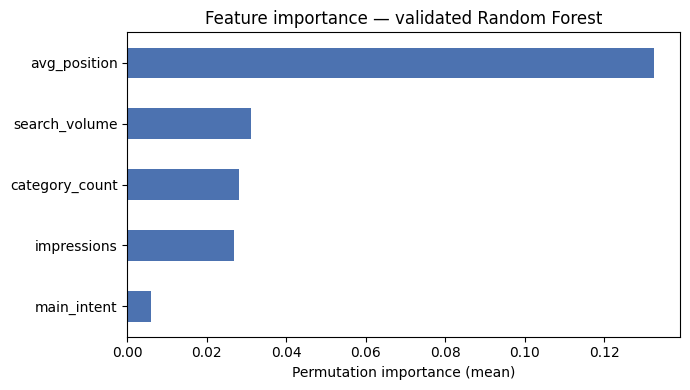

In [11]:
!pip install matplotlib --quiet

import os
import json
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

ranked_queue.to_csv("work/outputs/content_action_playbook.csv", index=False)

metrics = {
    **results_table,
    "queue_size": len(ranked_queue),
    "total_eligible_items": len(df),
    "queue_fraction_pct": round(len(ranked_queue) / len(df) * 100, 1),
    "eligibility_threshold_impressions": ELIGIBILITY_MIN_IMPRESSIONS,
    "score_threshold": SCORE_THRESHOLD,
}
with open("work/outputs/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

importance_series = pd.Series(importance_dict).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importance_series.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Permutation importance (mean)")
ax.set_title("Feature importance — validated Random Forest")
plt.tight_layout()
plt.savefig("work/figures/feature_importance.png", dpi=150)
plt.show()